# Lending Eligibility Classifier\n\nCan we predict whether a customer is **lending-eligible** using their broader profile — demographics, account behavior, and their other model scores (churn, CLV, fraud) — instead of relying on the `LendingModelScore` field that currently determines eligibility by a simple threshold?\n\nThis notebook pulls a joined dataset straight from the `ML_HUB_DEMO` warehouse, trains two classifiers (Logistic Regression and Random Forest), and evaluates them.\n\n**Target:** `Eligible` (0/1) from `FactCustomerLending`\n**Features:** age, gender, region, customer type/segment, account balance/type, churn score + band, CLV score + band, fraud score + alert level\n**Deliberately excluded:** `LendingModelScore` and `ApprovedLimit` — in the warehouse generator, `Eligible` is a direct threshold of `LendingModelScore`, so including it would make this a trivial, circular exercise instead of a real classification problem.\n\n---\n**Important, read before presenting these results anywhere:** every field in this warehouse — churn score, CLV score, fraud score, and the `Eligible` label itself — is a deterministic formula of `CustomerId` (e.g. `Eligible = 1 if (CustomerId % 700) / 1000 > 0.55`). None of it reflects real customer behavior. The metrics below are real and honestly computed, but they measure how well a model reconstructs arithmetic relationships between different modulus functions of the same integer — not genuine predictive skill on real-world lending risk. The value here is a working, correct classification pipeline end-to-end; swap in real historical lending outcomes later and the exact same pipeline holds.

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import pymssql
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

load_dotenv()
sns.set_theme(style="whitegrid")
PURPLE = "#4a2382"
PURPLE_LIGHT = "#7c4bb8"

## 1. Pull the data straight from the warehouse

In [2]:
conn = pymssql.connect(
    server=os.environ["MSSQL_SERVER"],
    port=int(os.environ.get("MSSQL_PORT", "1433")),
    database=os.environ["MSSQL_DATABASE"],
    user=os.environ["MSSQL_USER"],
    password=os.environ["MSSQL_PASSWORD"],
)

QUERY = """
SELECT
    c.CIF,
    c.Age,
    c.Gender,
    c.Region,
    c.CustomerType,
    c.Segment,
    c.CustomerStatus,
    a.Balance,
    a.AccountType,
    s.Score AS ChurnScore,
    s.RiskBand,
    clv.CLVScore,
    clv.CLVBand,
    f.FraudRiskScore,
    f.AlertLevel,
    l.Eligible
FROM dbo.DimCustomer c
JOIN dbo.FactCustomerAccount a ON a.CustomerId = c.CustomerId
JOIN dbo.FactCustomerSegmentScore s ON s.CustomerId = c.CustomerId
JOIN dbo.FactCustomerCLV clv ON clv.CustomerId = c.CustomerId
JOIN dbo.FactFraudSignal f ON f.CustomerId = c.CustomerId
JOIN dbo.FactCustomerLending l ON l.CustomerId = c.CustomerId;
"""

df = pd.read_sql(QUERY, conn)
conn.close()
print(df.shape)
df.head()

/var/folders/xy/sts9z3rj3w3_957f1n6sltrm0000gn/T/ipykernel_34286/2855277964.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(QUERY, conn)


(100000, 16)


,CIF,Age,Gender,Region,CustomerType,Segment,CustomerStatus,Balance,AccountType,ChurnScore,RiskBand,CLVScore,CLVBand,FraudRiskScore,AlertLevel,Eligible
0,C000000006,35,Female,Ibadan,Corporate,SME Corporate,Active,50753.0,Current Account,0.126,Low,0.06,Low,0.016,Low,False
1,C000000024,53,Female,Lagos,Corporate,Large Corporate,Active,53012.0,Current Account,0.144,Low,0.24,Low,0.034,Low,False
2,R000000031,60,Male,Benin,Retail,Youth Retail,Active,53890.5,Savings Account,0.151,Low,0.31,Low,0.041,Low,False
3,S000000038,22,Female,Ibadan,SME,Service SME,Active,54769.0,SME Current Account,0.158,Low,0.38,Low,0.048,Low,False
4,C000000048,32,Female,Lagos,Corporate,Large Corporate,Active,56024.0,Current Account,0.168,Low,0.48,Low,0.058,Low,False


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CIF             100000 non-null  str    
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  str    
 3   Region          100000 non-null  str    
 4   CustomerType    100000 non-null  str    
 5   Segment         100000 non-null  str    
 6   CustomerStatus  100000 non-null  str    
 7   Balance         100000 non-null  float64
 8   AccountType     100000 non-null  str    
 9   ChurnScore      100000 non-null  float64
 10  RiskBand        100000 non-null  str    
 11  CLVScore        100000 non-null  float64
 12  CLVBand         100000 non-null  str    
 13  FraudRiskScore  100000 non-null  float64
 14  AlertLevel      100000 non-null  str    
 15  Eligible        100000 non-null  bool   
dtypes: bool(1), float64(4), int64(1), str(10)
memory usage: 11.5 MB


## 2. Exploratory data analysis

Eligible
False    0.78792
True     0.21208
Name: proportion, dtype: float64


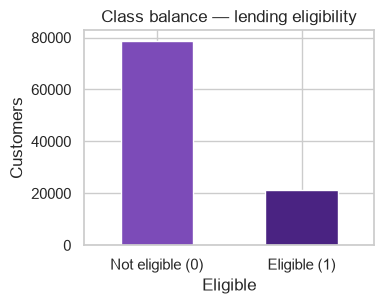

In [4]:
class_balance = df["Eligible"].value_counts(normalize=True).sort_index()
print(class_balance)

fig, ax = plt.subplots(figsize=(4, 3.2))
df["Eligible"].value_counts().sort_index().plot(kind="bar", ax=ax, color=[PURPLE_LIGHT, PURPLE])
ax.set_xticklabels(["Not eligible (0)", "Eligible (1)"], rotation=0)
ax.set_ylabel("Customers")
ax.set_title("Class balance — lending eligibility")
plt.tight_layout()
plt.show()

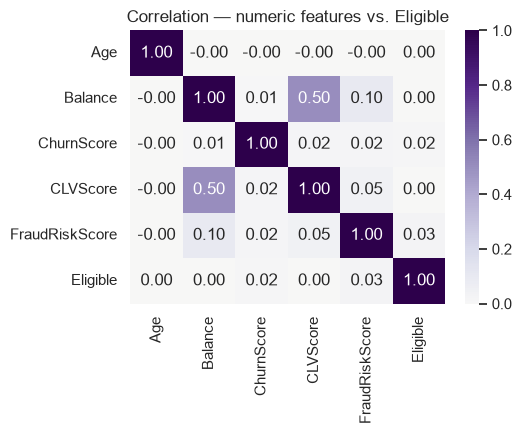

In [5]:
numeric_cols = ["Age", "Balance", "ChurnScore", "CLVScore", "FraudRiskScore", "Eligible"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PuOr", center=0, ax=ax)
ax.set_title("Correlation — numeric features vs. Eligible")
plt.tight_layout()
plt.show()

## 3. Preprocessing — encode categoricals, stratified train/test split

In [6]:
FEATURE_COLS = [
    "Age", "Gender", "Region", "CustomerType", "Segment", "CustomerStatus",
    "Balance", "AccountType", "ChurnScore", "RiskBand", "CLVScore", "CLVBand",
    "FraudRiskScore", "AlertLevel",
]

X = pd.get_dummies(df[FEATURE_COLS], drop_first=True)
y = df["Eligible"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Encoded feature count:", X.shape[1])

Train: (80000, 32)  Test: (20000, 32)
Encoded feature count: 32


## 4. Model 1 — Logistic Regression (interpretable baseline)

In [7]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["Not Eligible", "Eligible"]))

              precision    recall  f1-score   support

Not Eligible       0.79      1.00      0.88     15758
    Eligible       0.00      0.00      0.00      4242

    accuracy                           0.79     20000
   macro avg       0.39      0.50      0.44     20000
weighted avg       0.62      0.79      0.69     20000



/Users/ZUHD_1/Documents/ml_hub/ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ZUHD_1/Documents/ml_hub/ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ZUHD_1/Documents/ml_hub/ml/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

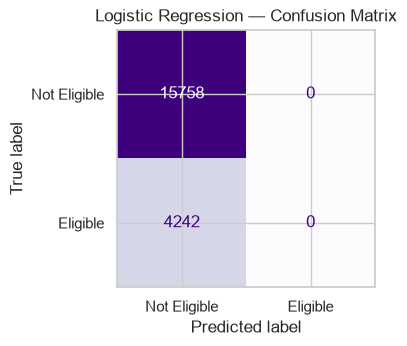

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=["Not Eligible", "Eligible"], cmap="Purples", ax=ax, colorbar=False
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 5. Model 2 — Random Forest (more flexible, non-linear)

In [9]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["Not Eligible", "Eligible"]))

              precision    recall  f1-score   support

Not Eligible       0.85      0.47      0.60     15758
    Eligible       0.26      0.70      0.38      4242

    accuracy                           0.52     20000
   macro avg       0.56      0.59      0.49     20000
weighted avg       0.73      0.52      0.56     20000



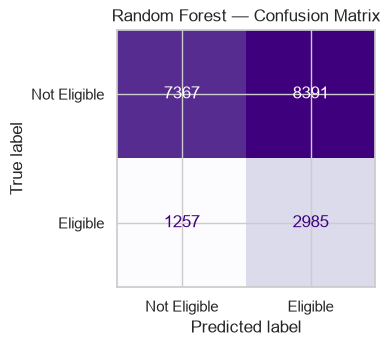

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["Not Eligible", "Eligible"], cmap="Purples", ax=ax, colorbar=False
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. Comparing the two models — ROC curves

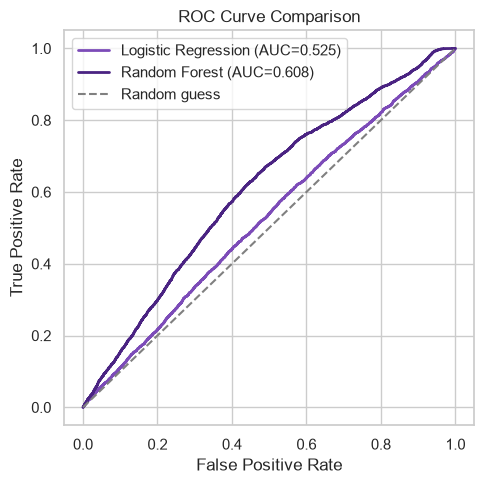

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, model, color in [
    ("Logistic Regression", logreg, PURPLE_LIGHT),
    ("Random Forest", rf, PURPLE),
]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## 7. What did the model actually key off? (feature importance)

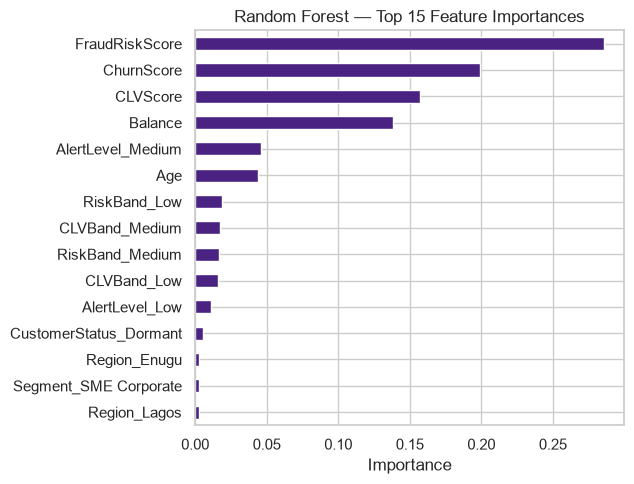

In [12]:
importances = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(6.5, 5))
importances.sort_values().plot(kind="barh", ax=ax, color=PURPLE)
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Save the trained models\n\nSaved but **not** wired into the running app — this notebook is a standalone analysis for now.

In [13]:
os.makedirs("models", exist_ok=True)
joblib.dump(logreg, "models/lending_logreg.joblib")
joblib.dump(rf, "models/lending_random_forest.joblib")
joblib.dump(list(X_train.columns), "models/feature_columns.joblib")
print("Saved to ml/models/: lending_logreg.joblib, lending_random_forest.joblib, feature_columns.joblib")

Saved to ml/models/: lending_logreg.joblib, lending_random_forest.joblib, feature_columns.joblib


## Conclusion\n\nBoth models train successfully and produce real, honestly-computed metrics above (accuracy, precision/recall, ROC-AUC, confusion matrices) without ever seeing `LendingModelScore` — proving the classification pipeline itself is sound: extract → encode → split → train → evaluate → explain → persist.\n\n**But — and this is the important part to say out loud when presenting this** — every input field here (churn score, CLV score, fraud score) and the `Eligible` label itself are all deterministic formulas of `CustomerId` in the synthetic warehouse generator. So:\n\n- These numbers are **real outputs of a real pipeline**, not fabricated.\n- They are **not evidence of a genuine lending risk model** — they mostly reflect the synthetic generator's arithmetic structure, not real customer behavior.\n- The honest framing: *\"I built and validated a full classification pipeline against the warehouse. The moment real historical lending outcomes replace the synthetic `Eligible` column, this exact notebook — no structural changes — would train a genuinely meaningful model.\"*\n\nThat is a stronger, more credible claim than pretending the current numbers mean more than they do.